# Entity Extraction: spaCy vs LLM Structured Output

Сравнение двух подходов к извлечению сущностей для конвейера построения графа знаний в задаче обнаружения галлюцинаций RAG.

**Что сравниваем:**
- `spaCy en_core_web_sm` - классический NER на dependency features.
- `Qwen2.5-7B-Instruct` (4-bit, unsloth) - LLM со structured JSON output, эквивалент по классу к Llama-3.1-8B из HalluGraph.

**Что меряем:**
- **DocRED (тестовый)** - оба экстрактора прогоняются против gold-разметки; считаем precision/recall/F1 для сущностей по каждой модели и отдельно precision/recall/F1 для триплетов LLM. По результату автоматически выбирается победитель: LLM берётся, если её F1 ≥ F1 spaCy − 0.05 (толерантность 5 п.п. учитывает, что LLM обычно даёт более дискриминативный сигнал для галлюцинаций даже при незначительном проигрыше по NER-полноте).
- **RAGTruth** - только победитель; считаем плотность графов сущностей контекста и ответа, EG-proxy (долю сущностей ответа, покрытых сущностями контекста) и его корреляцию с hallucination labels (AUROC). Дополнительно — разбивка по task_type (QA / Summary / Data2txt) для проверки high/low-regime по порогу плотности из HalluGraph.
- **XSum** - только победитель; те же метрики: плотность + EG-proxy на factuality annotations Maynez et al. 2020.


## 1. Установка и загрузка моделей

In [ ]:
!pip install -q spacy transformers accelerate bitsandbytes pandas datasets
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 45.8 MB/s eta 0:00:00


In [ ]:
import json, re, os, time, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import torch
import spacy
from transformers import AutoModelForCausalLM, AutoTokenizer

warnings.filterwarnings("ignore")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [ ]:
nlp = spacy.load("en_core_web_sm")
print("spaCy loaded:", nlp.pipe_names)

spaCy loaded: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


In [ ]:
LLM_NAME = "unsloth/Qwen2.5-7B-Instruct-bnb-4bit"

llm_tok = AutoTokenizer.from_pretrained(LLM_NAME)
llm_mdl = AutoModelForCausalLM.from_pretrained(
    LLM_NAME,
    device_map="auto",
    torch_dtype=torch.float16,
)
llm_mdl.eval()
# Убираем warning про max_length=32768 из встроенного generation_config Qwen
try:
    llm_mdl.generation_config.max_length = None
except Exception:
    pass
print("LLM loaded.")
print(f"VRAM used: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

config.json:   0%|          | 0.00/1.34k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.36k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 5.55GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

LLM loaded.
VRAM used: 5.55 GB


## 2. Функции извлечения

In [ ]:
def spacy_extract(text):
    doc = nlp(text)
    entities = list(set(ent.text.strip() for ent in doc.ents if len(ent.text.strip()) > 1))
    return {"entities": entities, "triplets": []}

In [ ]:
EXTRACTION_PROMPT = """You are a precise information extraction system.

Given the TEXT below, extract:
- ENTITIES: all named entities (people, organizations, locations, dates, works, etc.) as surface strings from the text.
- TRIPLETS: (subject, predicate, object) relations explicitly stated in the text. Predicates should be short verb phrases or Wikidata-like properties (e.g., "born in", "located in", "spouse of", "member of").

Output ONLY a JSON object matching the schema. No markdown code fences, no commentary.

Schema:
{
  "entities": ["entity string", ...],
  "triplets": [{"head": "...", "relation": "...", "tail": "..."}, ...]
}

TEXT:
\"\"\"
__TEXT__
\"\"\"

JSON:"""

def _safe_json_parse(raw):
    """Возвращает dict всегда, даже при любом сбое."""
    try:
        start = raw.find("{")
        end = raw.rfind("}")
        if start == -1 or end == -1 or end <= start:
            return {"entities": [], "triplets": []}
        candidate = raw[start:end + 1]
        candidate = re.sub(r"[\x00-\x1f]+", " ", candidate)
        try:
            obj = json.loads(candidate)
        except json.JSONDecodeError:
            candidate2 = re.sub(r",\s*([}\]])", r"\1", candidate)
            try:
                obj = json.loads(candidate2)
            except json.JSONDecodeError:
                return {"entities": [], "triplets": []}
        if not isinstance(obj, dict):
            return {"entities": [], "triplets": []}
        ents = [str(e).strip() for e in obj.get("entities", [])
                if isinstance(e, (str, int, float))]
        trips = []
        raw_trips = obj.get("triplets", [])
        if isinstance(raw_trips, list):
            for t in raw_trips:
                if isinstance(t, dict) and all(k in t for k in ("head", "relation", "tail")):
                    trips.append({
                        "head": str(t["head"]).strip(),
                        "relation": str(t["relation"]).strip(),
                        "tail": str(t["tail"]).strip(),
                    })
        return {"entities": ents, "triplets": trips}
    except Exception:
        return {"entities": [], "triplets": []}

def llm_extract(text, max_input_chars=3000, max_new_tokens=1024):
    """Гарантированно возвращает dict со списками entities и triplets."""
    try:
        text = text[:max_input_chars]
        prompt = EXTRACTION_PROMPT.replace("__TEXT__", text)
        messages = [{"role": "user", "content": prompt}]
        prompt_text = llm_tok.apply_chat_template(
            messages, add_generation_prompt=True, tokenize=False
        )
        inputs = llm_tok(prompt_text, return_tensors="pt").to(device)
        with torch.no_grad():
            out = llm_mdl.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=llm_tok.eos_token_id,
            )
        generated = llm_tok.decode(
            out[0][inputs["input_ids"].shape[1]:],
            skip_special_tokens=True,
        )
        return _safe_json_parse(generated)
    except Exception:
        return {"entities": [], "triplets": []}

# Sanity check
demo = "Barack Obama was born in Honolulu, Hawaii. He served as the 44th president of the United States and was married to Michelle Obama."
print("spaCy:", spacy_extract(demo))
print("LLM:", llm_extract(demo))

spaCy: {'entities': ['the United States', 'Honolulu', '44th', 'Michelle Obama', 'Barack Obama', 'Hawaii'], 'triplets': []}
LLM: {'entities': ['Barack Obama', 'Honolulu', 'Hawaii', 'United States', 'Michelle Obama'], 'triplets': [{'head': 'Barack Obama', 'relation': 'born in', 'tail': 'Honolulu'}, {'head': 'Barack Obama', 'relation': 'born in', 'tail': 'Hawaii'}, {'head': 'Barack Obama', 'relation': 'served as', 'tail': 'the 44th president of the United States'}, {'head': 'Barack Obama', 'relation': 'married to', 'tail': 'Michelle Obama'}]}


In [ ]:
def normalize(s):
    return re.sub(r"\s+", " ", str(s).strip().lower())

def soft_in(a, b, min_len=3):
    a, b = normalize(a), normalize(b)
    if not a or not b:
        return False
    if a == b:
        return True
    if len(a) >= min_len and len(b) >= min_len:
        return a in b or b in a
    return False

def count_entity_matches(pred_ents, gold_ents):
    matched = 0
    for pe in pred_ents:
        if any(soft_in(pe, ge) for ge in gold_ents):
            matched += 1
    return matched

def count_triplet_matches(pred_trips, gold_trips):
    matched = 0
    for pt in pred_trips:
        for gt in gold_trips:
            if soft_in(pt["head"], gt[0]) and soft_in(pt["tail"], gt[2]):
                matched += 1
                break
    return matched

def prf(matched, pred_total, gold_total):
    p = matched / pred_total if pred_total else 0.0
    r = matched / gold_total if gold_total else 0.0
    f = 2 * p * r / (p + r) if (p + r) else 0.0
    return round(p, 3), round(r, 3), round(f, 3)

# EG-score: доля сущностей ответа, покрытых сущностями контекста
def eg_score(response_ents, context_ents):
    if not response_ents:
        return 1.0
    matched = count_entity_matches(response_ents, set(map(str.lower, context_ents)))
    return matched / len(response_ents)

# AUROC без sklearn
def simple_auroc(scores, labels):
    scores = np.asarray(scores, dtype=float)
    labels = np.asarray(labels, dtype=int)
    if len(np.unique(labels)) < 2:
        return None
    risk = 1.0 - scores
    order = np.argsort(-risk)
    labels_sorted = labels[order]
    n_pos = labels.sum()
    n_neg = len(labels) - n_pos
    if n_pos == 0 or n_neg == 0:
        return None
    tp = np.cumsum(labels_sorted)
    fp = np.cumsum(1 - labels_sorted)
    tpr = tp / n_pos
    fpr = fp / n_neg
    return round(float(np.trapz(tpr, fpr)), 3)

## 3. Этап 1 — DocRED (валидация обеих моделей)

Из [папки Google Drive DocRED](https://drive.google.com/drive/folders/1c5-0YwnoJx8NS6CV2f-NoTHR__BdkNqw) загрузи в `/content/`:
- `dev.json`
- `rel_info.json`

Прогоняем обе модели, считаем precision/recall/F1. Результат используется для автоматического выбора победителя в следующей секции.

In [ ]:
DOCRED_DIR = Path("/content")
DEV_PATH = DOCRED_DIR / "dev.json"
REL_INFO_PATH = DOCRED_DIR / "rel_info.json"

assert DEV_PATH.exists(), "Загрузи dev.json в /content/"
assert REL_INFO_PATH.exists(), "Загрузи rel_info.json в /content/"

with open(DEV_PATH) as f:
    docred = json.load(f)
with open(REL_INFO_PATH) as f:
    rel_info = json.load(f)

def docred_to_text(doc):
    return " ".join(" ".join(sent) for sent in doc["sents"])

def docred_gold_entities(doc):
    ents = set()
    for cluster in doc["vertexSet"]:
        for m in cluster:
            ents.add(m["name"].strip().lower())
    return ents

def docred_gold_triplets(doc, rel_info):
    trips = []
    for lbl in doc.get("labels", []):
        h = doc["vertexSet"][lbl["h"]][0]["name"]
        t = doc["vertexSet"][lbl["t"]][0]["name"]
        r = rel_info.get(lbl["r"], lbl["r"])
        trips.append((h.strip().lower(), r.strip().lower(), t.strip().lower()))
    return trips

print(f"Loaded {len(docred)} DocRED docs")

Loaded 998 DocRED docs


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── параметры ──────────────────────────────────────────────
N_DOCRED   = 50     # для валидации достаточно; 100 = ~2× дольше
MAX_CHARS  = 1500   # ~450 токенов промпт; было 2000 (~600 токенов) — быстрее на 25%
BATCH_SIZE = 4     # T4 + Qwen 7B 4-bit; при OOM поставь 2

# Короткий промпт — меньше токенов на prefill
SHORT_PROMPT = """Extract named entities and relations from the TEXT as JSON only.

Schema: {{"entities": ["..."], "triplets": [{{"head":"...","relation":"...","tail":"..."}}]}}

TEXT: \"\"\"{text}\"\"\"

JSON:"""

def llm_extract_batch(texts, max_new_tokens=384):
    # 1. Строим промпты
    prompts = []
    for t in texts:
        t = t[:MAX_CHARS]
        msg = [{"role": "user", "content": SHORT_PROMPT.format(text=t)}]
        prompts.append(
            llm_tok.apply_chat_template(msg, add_generation_prompt=True, tokenize=False)
        )

    # 2. Токенизируем с left-padding
    llm_tok.padding_side = "left"
    inputs = llm_tok(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=1536,        # с запасом под промпт + немного decode
    ).to(device)

    # 3. Генерируем
    with torch.no_grad():
        out = llm_mdl.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],   # явно — без этого padding игнорируется
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=llm_tok.eos_token_id,
        )

    # 4. Декодируем: для каждой строки батча свой реальный input_len
    results = []
    for idx in range(len(prompts)):
        # attention_mask[idx] == 1 только для реальных токенов (не padding)
        real_input_len = int(inputs["attention_mask"][idx].sum())
        generated = llm_tok.decode(
            out[idx][real_input_len:],
            skip_special_tokens=True,
        )
        results.append(_safe_json_parse(generated))
    return results

# ── основной цикл ──────────────────────────────────────────
docred_rows = []
t0 = time.time()
docs = docred[:N_DOCRED]

for batch_start in range(0, len(docs), BATCH_SIZE):
    batch_docs = docs[batch_start : batch_start + BATCH_SIZE]
    texts = [docred_to_text(d)[:MAX_CHARS] for d in batch_docs]

    sp_results = [spacy_extract(t) for t in texts]

    try:
        lm_results = llm_extract_batch(texts)
    except RuntimeError as e:
        if "CUDA out of memory" in str(e):
            torch.cuda.empty_cache()
            print(f"[batch {batch_start}] OOM — попробуй BATCH_SIZE = 2")
        else:
            print(f"[batch {batch_start}] failed: {e}")
        lm_results = [{"entities": [], "triplets": []}] * len(batch_docs)

    for j, doc in enumerate(batch_docs):
        i = batch_start + j
        gold_ents  = docred_gold_entities(doc)
        gold_trips = docred_gold_triplets(doc, rel_info)
        sp_ents    = sp_results[j].get("entities", [])
        lm_ents    = lm_results[j].get("entities", [])
        lm_trips   = lm_results[j].get("triplets", [])

        docred_rows.append({
            "doc_id":               i,
            "title":                doc.get("title", ""),
            "n_words":              len(texts[j].split()),
            "gold_ents":            len(gold_ents),
            "gold_trips":           len(gold_trips),
            "spacy_ents":           len(sp_ents),
            "spacy_ents_matched":   count_entity_matches(sp_ents, gold_ents),
            "llm_ents":             len(lm_ents),
            "llm_ents_matched":     count_entity_matches(lm_ents, gold_ents),
            "llm_trips":            len(lm_trips),
            "llm_trips_matched":    count_triplet_matches(lm_trips, gold_trips),
        })

    done = min(batch_start + BATCH_SIZE, N_DOCRED)
    print(f"[{done:3d}/{N_DOCRED}] {time.time()-t0:5.0f}s  "
          f"| llm_ents этого батча: {[len(r.get('entities',[])) for r in lm_results]}")

docred_df = pd.DataFrame(docred_rows)
print(f"\nDone. Всего строк: {len(docred_df)}")
print(f"LLM пустых графов: {(docred_df['llm_ents'] == 0).sum()} / {N_DOCRED}")
docred_df.head()

[  4/50]   211s  | llm_ents этого батча: [9, 0, 0, 0]
[  8/50]   423s  | llm_ents этого батча: [0, 0, 0, 0]
[ 12/50]   632s  | llm_ents этого батча: [0, 11, 0, 0]
[ 16/50]   842s  | llm_ents этого батча: [11, 9, 0, 0]
[ 20/50]  1051s  | llm_ents этого батча: [0, 0, 14, 0]
[ 24/50]  1261s  | llm_ents этого батча: [0, 0, 0, 7]
[ 28/50]  1471s  | llm_ents этого батча: [13, 0, 8, 0]
[ 32/50]  1681s  | llm_ents этого батча: [0, 0, 0, 0]
[ 36/50]  1889s  | llm_ents этого батча: [0, 0, 0, 0]
[ 40/50]  2101s  | llm_ents этого батча: [0, 0, 0, 0]
[ 44/50]  2313s  | llm_ents этого батча: [0, 0, 13, 0]
[ 48/50]  2525s  | llm_ents этого батча: [0, 0, 0, 0]
[ 50/50]  2727s  | llm_ents этого батча: [0, 0]

Done. Всего строк: 50
LLM пустых графов: 41 / 50


,doc_id,title,n_words,gold_ents,gold_trips,spacy_ents,spacy_ents_matched,llm_ents,llm_ents_matched,llm_trips,llm_trips_matched
0,0,Skai TV,165,10,7,10,9,9,9,10,2
1,1,Washington Place (West Virginia),138,20,17,20,17,0,0,0,0
2,2,IBM Research – Brazil,246,16,11,20,13,0,0,0,0
3,3,Lookin Ass,159,18,6,19,18,0,0,0,0
4,4,Conrad O. Johnson,282,26,21,31,26,0,0,0,0


In [ ]:
sp_ent_p, sp_ent_r, sp_ent_f = prf(
    docred_df["spacy_ents_matched"].sum(),
    docred_df["spacy_ents"].sum(),
    docred_df["gold_ents"].sum(),
)
lm_ent_p, lm_ent_r, lm_ent_f = prf(
    docred_df["llm_ents_matched"].sum(),
    docred_df["llm_ents"].sum(),
    docred_df["gold_ents"].sum(),
)
lm_trip_p, lm_trip_r, lm_trip_f = prf(
    docred_df["llm_trips_matched"].sum(),
    docred_df["llm_trips"].sum(),
    docred_df["gold_trips"].sum(),
)

docred_summary = pd.DataFrame([
    {"dataset": "DocRED", "model": "spacy", "level": "entities",
     "extracted": int(docred_df["spacy_ents"].sum()),
     "matched": int(docred_df["spacy_ents_matched"].sum()),
     "gold": int(docred_df["gold_ents"].sum()),
     "precision": sp_ent_p, "recall": sp_ent_r, "f1": sp_ent_f},
    {"dataset": "DocRED", "model": "llm", "level": "entities",
     "extracted": int(docred_df["llm_ents"].sum()),
     "matched": int(docred_df["llm_ents_matched"].sum()),
     "gold": int(docred_df["gold_ents"].sum()),
     "precision": lm_ent_p, "recall": lm_ent_r, "f1": lm_ent_f},
    {"dataset": "DocRED", "model": "llm", "level": "triplets",
     "extracted": int(docred_df["llm_trips"].sum()),
     "matched": int(docred_df["llm_trips_matched"].sum()),
     "gold": int(docred_df["gold_trips"].sum()),
     "precision": lm_trip_p, "recall": lm_trip_r, "f1": lm_trip_f},
])

OUT = Path("/content/results")
OUT.mkdir(exist_ok=True)
docred_df.to_csv(OUT / "docred_perdoc.csv", index=False)
docred_summary.to_csv(OUT / "docred_summary.csv", index=False)

print("=== DocRED summary ===")
print(docred_summary.to_string(index=False))

=== DocRED summary ===
dataset model    level  extracted  matched  gold  precision  recall    f1
 DocRED spacy entities        983      872   999      0.887   0.873 0.880
 DocRED   llm entities         95       85   999      0.895   0.085 0.155
 DocRED   llm triplets         84       21   684      0.250   0.031 0.055


## 4. Автоматический выбор победителя

**Правило:** если F1 LLM по сущностям ≥ F1 spaCy - 0.05, выбираем LLM. Иначе - spaCy.

Толерантность в 5 п.п. отражает то, что LLM обычно даёт лучший дискриминативный сигнал для метрики EG (за счёт того, что извлекает более семантически осмысленные, а не поверхностно-грамматические сущности), даже если чуть уступает по чистой NER-полноте на DocRED.

In [ ]:
TOLERANCE = 0.05

if lm_ent_f >= sp_ent_f - TOLERANCE:
    WINNER = "llm"
    winner_extract = llm_extract
else:
    WINNER = "spacy"
    winner_extract = spacy_extract

print(f"spaCy F1 (entities): {sp_ent_f}")
print(f"LLM   F1 (entities): {lm_ent_f}")
print(f"Разница: {lm_ent_f - sp_ent_f:+.3f}, порог: -{TOLERANCE}")
print(f"\n>>> WINNER: {WINNER.upper()} <<<")
print(f"Дальше RAGTruth и XSum прогоняются функцией {winner_extract.__name__}")

spaCy F1 (entities): 0.88
LLM   F1 (entities): 0.155
Разница: -0.725, порог: -0.05

>>> WINNER: SPACY <<<
Дальше RAGTruth и XSum прогоняются функцией spacy_extract


## 5. Этап 2 — RAGTruth

Из [ParticleMedia/RAGTruth](https://github.com/ParticleMedia/RAGTruth) загружаем `dataset/response.jsonl` и `dataset/source_info.jsonl`.

Считаем:
- **Плотность** графов сущностей контекста и ответа (порог HalluGraph = 20 сущностей).
- **EG-score** — доля сущностей ответа, покрытых сущностями контекста.
- **AUROC(EG → hallucination)** — насколько EG-сигнал победителя разделяет галлюцинированные и честные ответы.

In [ ]:
import json
from pathlib import Path

RAGTRUTH_DIR = Path("/content")
RT_RESPONSE  = RAGTRUTH_DIR / "response.jsonl"
RT_SOURCE    = RAGTRUTH_DIR / "source_info.jsonl"

def load_jsonl(path):
    records = []
    skipped = 0
    with open(path, encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                skipped += 1
    if skipped:
        print(f"  Пропущено битых строк в {path.name}: {skipped}")
    return records

if RT_RESPONSE.exists() and RT_SOURCE.exists():
    rt_responses = load_jsonl(RT_RESPONSE)
    rt_sources   = {s["source_id"]: s for s in load_jsonl(RT_SOURCE)}
    print(f"RAGTruth: {len(rt_responses)} responses, {len(rt_sources)} sources")
else:
    print("Файлы не найдены — загрузи response.jsonl и source_info.jsonl в /content/")
    rt_responses, rt_sources = [], {}

# проверка размера файлов
import os
for p in [RT_RESPONSE, RT_SOURCE]:
    if p.exists():
        print(f"{p.name}: {os.path.getsize(p)/1e6:.1f} MB")

  Пропущено битых строк в response.jsonl: 1
  Пропущено битых строк в source_info.jsonl: 1
RAGTruth: 9512 responses, 425 sources
response.jsonl: 11.5 MB
source_info.jsonl: 3.1 MB


In [ ]:
N_RAGTRUTH = 9900

def source_text(source_info):
    src = source_info.get("source_info", source_info.get("source", ""))
    if isinstance(src, dict):
        src = json.dumps(src, ensure_ascii=False)
    return str(src)

rt_rows = []
if rt_responses:
    t0 = time.time()
    for i, resp in enumerate(rt_responses[:N_RAGTRUTH]):
        src = rt_sources.get(resp["source_id"], {})
        ctx = source_text(src)[:MAX_CHARS]
        answer = resp.get("response", "")[:MAX_CHARS]
        is_hallucinated = 1 if resp.get("labels") else 0

        ctx_full = winner_extract(ctx) or {"entities": [], "triplets": []}
        ans_full = winner_extract(answer) or {"entities": [], "triplets": []}
        ctx_ents = ctx_full.get("entities", [])
        ans_ents = ans_full.get("entities", [])
        ans_trips = ans_full.get("triplets", [])

        rt_rows.append({
            "resp_id": resp.get("id", i),
            "task_type": src.get("task_type", "?"),
            "gen_model": resp.get("model", "?"),
            "hallucinated": is_hallucinated,
            "ctx_ents": len(ctx_ents),
            "ans_ents": len(ans_ents),
            "ans_trips": len(ans_trips),
            "eg": eg_score(ans_ents, ctx_ents),
        })
        if (i + 1) % 10 == 0:
            print(f"[{i+1}/{N_RAGTRUTH}] elapsed {time.time()-t0:.0f}s")

    ragtruth_df = pd.DataFrame(rt_rows)
    ragtruth_df.to_csv(OUT / "ragtruth_perdoc.csv", index=False)
    print("\nDone.")
else:
    ragtruth_df = pd.DataFrame()
    print("Skipped RAGTruth.")

if not ragtruth_df.empty:
    ragtruth_df.head()

[10/9900] elapsed 1s
[20/9900] elapsed 1s
[30/9900] elapsed 2s
[40/9900] elapsed 3s
[50/9900] elapsed 4s
[60/9900] elapsed 5s
[70/9900] elapsed 6s
[80/9900] elapsed 6s
[90/9900] elapsed 7s
[100/9900] elapsed 7s
[110/9900] elapsed 8s
[120/9900] elapsed 8s
[130/9900] elapsed 9s
[140/9900] elapsed 9s
[150/9900] elapsed 10s
[160/9900] elapsed 10s
[170/9900] elapsed 11s
[180/9900] elapsed 12s
[190/9900] elapsed 12s
[200/9900] elapsed 13s
[210/9900] elapsed 14s
[220/9900] elapsed 14s
[230/9900] elapsed 15s
[240/9900] elapsed 15s
[250/9900] elapsed 16s
[260/9900] elapsed 17s
[270/9900] elapsed 18s
[280/9900] elapsed 19s
[290/9900] elapsed 20s
[300/9900] elapsed 21s
[310/9900] elapsed 21s
[320/9900] elapsed 22s
[330/9900] elapsed 22s
[340/9900] elapsed 23s
[350/9900] elapsed 23s
[360/9900] elapsed 24s
[370/9900] elapsed 24s
[380/9900] elapsed 25s
[390/9900] elapsed 25s
[400/9900] elapsed 26s
[410/9900] elapsed 26s
[420/9900] elapsed 27s
[430/9900] elapsed 28s
[440/9900] elapsed 28s
[450/9900] 

In [ ]:
# ── разбивка ragtruth_df по task_type ─────────────────────
THRESHOLD = 20

print("=== Распределение по task_type ===")
print(ragtruth_df["task_type"].value_counts().to_string())
print()

task_stats = ragtruth_df.groupby("task_type").agg(
    n               = ("resp_id", "count"),
    hallu_rate      = ("hallucinated", "mean"),
    median_ctx_ents = ("ctx_ents", "median"),
    median_ans_ents = ("ans_ents", "median"),
    pct_empty_ans   = ("ans_ents", lambda x: (x == 0).mean() * 100),
    mean_eg         = ("eg", "mean"),
).round(3)

task_stats["regime"] = task_stats["median_ctx_ents"].apply(
    lambda m: "HIGH ✓" if m >= THRESHOLD else "LOW ✗"
)

print("=== Метрики по task_type ===")
print(task_stats.to_string())
print()

# ── сохранить каждую подзадачу отдельно ───────────────────
for task in ragtruth_df["task_type"].unique():
    subset = ragtruth_df[ragtruth_df["task_type"] == task].reset_index(drop=True)
    fname  = f"ragtruth_{task.lower().replace(' ', '_')}.csv"
    subset.to_csv(OUT / fname, index=False)
    print(f"Сохранено: {fname} ({len(subset)} строк, "
          f"hallu_rate={subset['hallucinated'].mean():.2f}, "
          f"median_ctx={subset['ctx_ents'].median():.0f}, "
          f"median_ans={subset['ans_ents'].median():.0f})")

=== Распределение по task_type ===
task_type
?          6962
Summary    2550

=== Метрики по task_type ===
              n  hallu_rate  median_ctx_ents  median_ans_ents  pct_empty_ans  mean_eg  regime
task_type                                                                                    
?          6962       0.521              0.0              9.0          0.029    0.000   LOW ✗
Summary    2550       0.286             21.0              9.0          0.078    0.759  HIGH ✓

Сохранено: ragtruth_summary.csv (2550 строк, hallu_rate=0.29, median_ctx=21, median_ans=9)
Сохранено: ragtruth_?.csv (6962 строк, hallu_rate=0.52, median_ctx=0, median_ans=9)


In [ ]:
if not ragtruth_df.empty:
    auroc = simple_auroc(ragtruth_df["eg"].values, ragtruth_df["hallucinated"].values)
    ragtruth_summary = pd.DataFrame([{
        "dataset": "RAGTruth",
        "extractor": WINNER,
        "n_samples": int(len(ragtruth_df)),
        "median_ctx_ents": int(ragtruth_df["ctx_ents"].median()),
        "median_ans_ents": int(ragtruth_df["ans_ents"].median()),
        "empty_ans_graphs": int((ragtruth_df["ans_ents"] == 0).sum()),
        "mean_eg": round(float(ragtruth_df["eg"].mean()), 3),
        "auroc_eg_hallu": auroc,
    }])
    ragtruth_summary.to_csv(OUT / "ragtruth_summary.csv", index=False)
    print("=== RAGTruth summary ===")
    print(ragtruth_summary.to_string(index=False))

    # Разбивка по task_type — полезно для понимания high/low regime по HalluGraph
    by_task = ragtruth_df.groupby("task_type").agg(
        n=("resp_id", "count"),
        median_ctx_ents=("ctx_ents", "median"),
        median_ans_ents=("ans_ents", "median"),
        mean_eg=("eg", "mean"),
        hallu_rate=("hallucinated", "mean"),
    ).round(3)
    print("\n=== RAGTruth by task_type ===")
    print(by_task.to_string())
else:
    ragtruth_summary = pd.DataFrame()

=== RAGTruth summary ===
 dataset extractor  n_samples  median_ctx_ents  median_ans_ents  empty_ans_graphs  mean_eg  auroc_eg_hallu
RAGTruth     spacy       9512                0                9                 4    0.204           0.658

=== RAGTruth by task_type ===
              n  median_ctx_ents  median_ans_ents  mean_eg  hallu_rate
task_type                                                             
?          6962              0.0              9.0    0.000       0.521
Summary    2550             21.0              9.0    0.759       0.286


## 6. Этап 3 — XSum

Из [google-research-datasets/xsum_hallucination_annotations](https://github.com/google-research-datasets/xsum_hallucination_annotations) загружаем `hallucination_annotations_xsum_summaries.csv`.

Source-статьи подтянутся из HuggingFace `EdinburghNLP/xsum` автоматически.

In [ ]:
XSUM_CSV = Path("/content/hallucination_annotations_xsum_summaries.csv")
xsum_df_raw = None
xsum_source_map = {}

if XSUM_CSV.exists():
    xsum_df_raw = pd.read_csv(XSUM_CSV)
    print(f"Loaded {len(xsum_df_raw)} XSum annotation rows")
    print("Columns:", list(xsum_df_raw.columns))
    print(xsum_df_raw.head(2))

    try:
        from datasets import load_dataset
        xsum_hf = load_dataset("EdinburghNLP/xsum", split="test")
        xsum_source_map = {row["id"]: row["document"] for row in xsum_hf}
        print(f"Loaded {len(xsum_source_map)} source articles")
    except Exception as e:
        print(f"HF xsum failed: {e}")
else:
    print("XSum CSV не найден — пропусти секцию.")

Loaded 11185 XSum annotation rows
Columns: ['bbcid', 'system', 'summary', 'hallucination_type', 'hallucinated_span', 'hallucinated_span_start', 'hallucinated_span_end', 'worker_id']
      bbcid   system                                            summary  \
0  34687720  BERTS2S  rory mcilroy will take a one-shot lead into th...   
1  34687720  BERTS2S  rory mcilroy will take a one-shot lead into th...   

  hallucination_type                                  hallucinated_span  \
0          extrinsic  rory mcilroy will take a one-shot lead into th...   
1          extrinsic  rory mcilroy will take a one-shot lead into th...   

   hallucinated_span_start  hallucinated_span_end worker_id  
0                        1                    114     wid_0  
1                        1                    114     wid_1  


README.md:   0%|          | 0.00/6.42k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  300MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 16.4MB            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/204045 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/11332 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11334 [00:00<?, ? examples/s]

Loaded 11334 source articles


In [ ]:
N_XSUM = 11000
xsum_rows = []

if xsum_df_raw is not None and xsum_source_map:
    id_col = next((c for c in xsum_df_raw.columns if "bbcid" in c.lower() or c.lower() == "id"), None)
    hallu_col = next((c for c in xsum_df_raw.columns
                      if "hallucination" in c.lower() or "factual" in c.lower()), None)
    summary_col = next((c for c in xsum_df_raw.columns if "summary" in c.lower()), None)

    print(f"id_col={id_col}, hallu_col={hallu_col}, summary_col={summary_col}")

    if id_col and summary_col:
        subset = xsum_df_raw[[id_col, summary_col] + ([hallu_col] if hallu_col else [])].drop_duplicates(
            subset=[id_col, summary_col]
        )
        subset = subset.head(N_XSUM)

        t0 = time.time()
        for i, row in subset.iterrows():
            bbcid = str(row[id_col])
            summary = str(row[summary_col])[:MAX_CHARS]
            source = xsum_source_map.get(bbcid, "")[:MAX_CHARS]
            if not source:
                continue
            hallu = 1 if hallu_col and str(row[hallu_col]).lower() not in ("factual", "no", "false", "0", "nan") else 0

            ctx_full = winner_extract(source) or {"entities": [], "triplets": []}
            ans_full = winner_extract(summary) or {"entities": [], "triplets": []}
            ctx_ents = ctx_full.get("entities", [])
            ans_ents = ans_full.get("entities", [])
            ans_trips = ans_full.get("triplets", [])

            xsum_rows.append({
                "bbcid": bbcid,
                "hallucinated": hallu,
                "ctx_ents": len(ctx_ents),
                "ans_ents": len(ans_ents),
                "ans_trips": len(ans_trips),
                "eg": eg_score(ans_ents, ctx_ents),
            })
            if len(xsum_rows) % 10 == 0:
                print(f"[{len(xsum_rows)}] elapsed {time.time()-t0:.0f}s")

        xsum_df = pd.DataFrame(xsum_rows)
        xsum_df.to_csv(OUT / "xsum_perdoc.csv", index=False)
        print("\nDone.")
    else:
        print("Не нашёл нужных колонок в XSum CSV.")
        xsum_df = pd.DataFrame()
else:
    xsum_df = pd.DataFrame()
    print("Skipped XSum.")

if not xsum_df.empty:
    xsum_df.head()

id_col=bbcid, hallu_col=hallucination_type, summary_col=summary
[10] elapsed 1s
[20] elapsed 2s
[30] elapsed 3s
[40] elapsed 6s
[50] elapsed 10s
[60] elapsed 11s
[70] elapsed 11s
[80] elapsed 13s
[90] elapsed 14s
[100] elapsed 16s
[110] elapsed 16s
[120] elapsed 17s
[130] elapsed 18s
[140] elapsed 18s
[150] elapsed 19s
[160] elapsed 19s
[170] elapsed 20s
[180] elapsed 20s
[190] elapsed 21s
[200] elapsed 21s
[210] elapsed 22s
[220] elapsed 23s
[230] elapsed 23s
[240] elapsed 24s
[250] elapsed 25s
[260] elapsed 25s
[270] elapsed 26s
[280] elapsed 26s
[290] elapsed 26s
[300] elapsed 27s
[310] elapsed 27s
[320] elapsed 27s
[330] elapsed 28s
[340] elapsed 28s
[350] elapsed 29s
[360] elapsed 29s
[370] elapsed 29s
[380] elapsed 30s
[390] elapsed 30s
[400] elapsed 31s
[410] elapsed 31s
[420] elapsed 32s
[430] elapsed 32s
[440] elapsed 32s
[450] elapsed 33s
[460] elapsed 33s
[470] elapsed 34s
[480] elapsed 34s
[490] elapsed 34s
[500] elapsed 35s
[510] elapsed 36s
[520] elapsed 36s
[530] elapsed

In [ ]:
if not xsum_df.empty:
    auroc = simple_auroc(xsum_df["eg"].values, xsum_df["hallucinated"].values)
    xsum_summary = pd.DataFrame([{
        "dataset": "XSum",
        "extractor": WINNER,
        "n_samples": int(len(xsum_df)),
        "median_ctx_ents": int(xsum_df["ctx_ents"].median()),
        "median_ans_ents": int(xsum_df["ans_ents"].median()),
        "empty_ans_graphs": int((xsum_df["ans_ents"] == 0).sum()),
        "mean_eg": round(float(xsum_df["eg"].mean()), 3),
        "auroc_eg_hallu": auroc,
    }])
    xsum_summary.to_csv(OUT / "xsum_summary.csv", index=False)
    print("=== XSum summary ===")
    print(xsum_summary.to_string(index=False))
else:
    xsum_summary = pd.DataFrame()

=== XSum summary ===
dataset extractor  n_samples  median_ctx_ents  median_ans_ents  empty_ans_graphs  mean_eg  auroc_eg_hallu
   XSum     spacy       2494               18                2               436    0.608           0.611


In [ ]:
import os
for f in sorted(os.listdir("/content")):
    print(f)

.config
dev.json
drive
hallucination_annotations_xsum_summaries.csv
rel_info.json
response.jsonl
results
sample_data
source_info.jsonl


In [ ]:
import os, pandas as pd
from datasets import load_dataset
from pathlib import Path

OUT = Path("/content/results")

# ── загрузка с правильным именем файла ────────────────────
xsum_df     = pd.read_csv(OUT / "xsum_perdoc.csv")
xsum_df_raw = pd.read_csv("/content/hallucination_annotations_xsum_summaries.csv")

xsum_hf        = load_dataset("EdinburghNLP/xsum", split="test")
xsum_source_map = {row["id"]: row["document"] for row in xsum_hf}

id_col      = next(c for c in xsum_df_raw.columns if "bbcid" in c.lower() or c.lower() == "id")
summary_col = next(c for c in xsum_df_raw.columns if "summary" in c.lower())
hallu_col   = next((c for c in xsum_df_raw.columns
                    if "hallucination" in c.lower() or "factual" in c.lower()), None)

print("Колонки:", list(xsum_df_raw.columns))
print(f"id_col={id_col}, summary_col={summary_col}, hallu_col={hallu_col}\n")

# ── примеры пустых графов ─────────────────────────────────
empty_ids = xsum_df[xsum_df["ans_ents"] == 0]["bbcid"].astype(str).tolist()
subset    = xsum_df_raw[xsum_df_raw[id_col].astype(str).isin(empty_ids)].head(5)

print(f"Всего пустых графов: {len(empty_ids)} из {len(xsum_df)} "
      f"({len(empty_ids)/len(xsum_df)*100:.0f}%)\n")
print("=" * 80)

for _, row in subset.iterrows():
    bbcid   = str(row[id_col])
    summary = str(row[summary_col])
    hallu   = str(row[hallu_col]) if hallu_col else "?"
    source  = xsum_source_map.get(bbcid, "")[:500]
    ents    = nlp(summary).ents

    print(f"BBC ID: {bbcid}")
    print(f"Hallucination label: {hallu}")
    print(f"SUMMARY: {summary}")
    print(f"spaCy entities: {[e.text for e in ents]}")
    print(f"SOURCE (500 chars): {source}")
    print("=" * 80)

Колонки: ['bbcid', 'system', 'summary', 'hallucination_type', 'hallucinated_span', 'hallucinated_span_start', 'hallucinated_span_end', 'worker_id']
id_col=bbcid, summary_col=summary, hallu_col=hallucination_type

Всего пустых графов: 436 из 2494 (17%)

BBC ID: 21267591
Hallucination label: nan
SUMMARY: the leader of bahrain\'s main opposition party has said there needs to be dialogue between the kingdom\'s crown prince and government.
spaCy entities: ['bahrain\\', 'kingdom\\']
SOURCE (500 chars): Sheikh Ali Salman told the BBC that for national dialogue to be meaningful, the government had to show its willingness to offer "concrete solutions".
"We want someone who can speak for the royal family," he said.
Crown Prince Salman al-Khalifa is seen as a reformist in a court divided on how to respond to opposition demands.
Hardliners - centred around the unelected Prime Minister Sheikh Khalifa bin Salman al-Khalifa, who has been in his post since 1971 - are said to be opposed to a dialogue p

## 7. Итоговая сводка и сохранение

In [ ]:
parts = [docred_summary]
if not ragtruth_summary.empty:
    parts.append(ragtruth_summary)
if not xsum_summary.empty:
    parts.append(xsum_summary)

full_summary = pd.concat(parts, ignore_index=True, sort=False)
full_summary.to_csv(OUT / "full_summary.csv", index=False)

report = {
    "spacy_model": "en_core_web_sm",
    "llm_model": LLM_NAME,
    "tolerance_for_winner": TOLERANCE,
    "winner": WINNER,
    "docred_spacy_f1_ents": sp_ent_f,
    "docred_llm_f1_ents": lm_ent_f,
    "n_docred": int(len(docred_df)) if not docred_df.empty else 0,
    "n_ragtruth": int(len(ragtruth_df)) if not ragtruth_df.empty else 0,
    "n_xsum": int(len(xsum_df)) if not xsum_df.empty else 0,
    "summary": full_summary.to_dict(orient="records"),
}
with open(OUT / "full_report.json", "w") as f:
    json.dump(report, f, indent=2, ensure_ascii=False)

print(f">>> WINNER: {WINNER.upper()} (spaCy F1 = {sp_ent_f}, LLM F1 = {lm_ent_f}) <<<\n")
print("=== FULL SUMMARY ===")
print(full_summary.to_string(index=False))
print("\nSaved:")
for p in sorted(OUT.iterdir()):
    print(" ", p)

>>> WINNER: SPACY (spaCy F1 = 0.88, LLM F1 = 0.155) <<<

=== FULL SUMMARY ===
 dataset model    level  extracted  matched  gold  precision  recall    f1 extractor  n_samples  median_ctx_ents  median_ans_ents  empty_ans_graphs  mean_eg  auroc_eg_hallu
  DocRED spacy entities      983.0    872.0 999.0      0.887   0.873 0.880       NaN        NaN              NaN              NaN               NaN      NaN             NaN
  DocRED   llm entities       95.0     85.0 999.0      0.895   0.085 0.155       NaN        NaN              NaN              NaN               NaN      NaN             NaN
  DocRED   llm triplets       84.0     21.0 684.0      0.250   0.031 0.055       NaN        NaN              NaN              NaN               NaN      NaN             NaN
RAGTruth   NaN      NaN        NaN      NaN   NaN        NaN     NaN   NaN     spacy     9512.0              0.0              9.0               4.0    0.204           0.658
    XSum   NaN      NaN        NaN      NaN   NaN        

In [ ]:
from google.colab import files
for p in sorted(OUT.glob("*.csv")):
    files.download(str(p))
files.download(str(OUT / "full_report.json"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

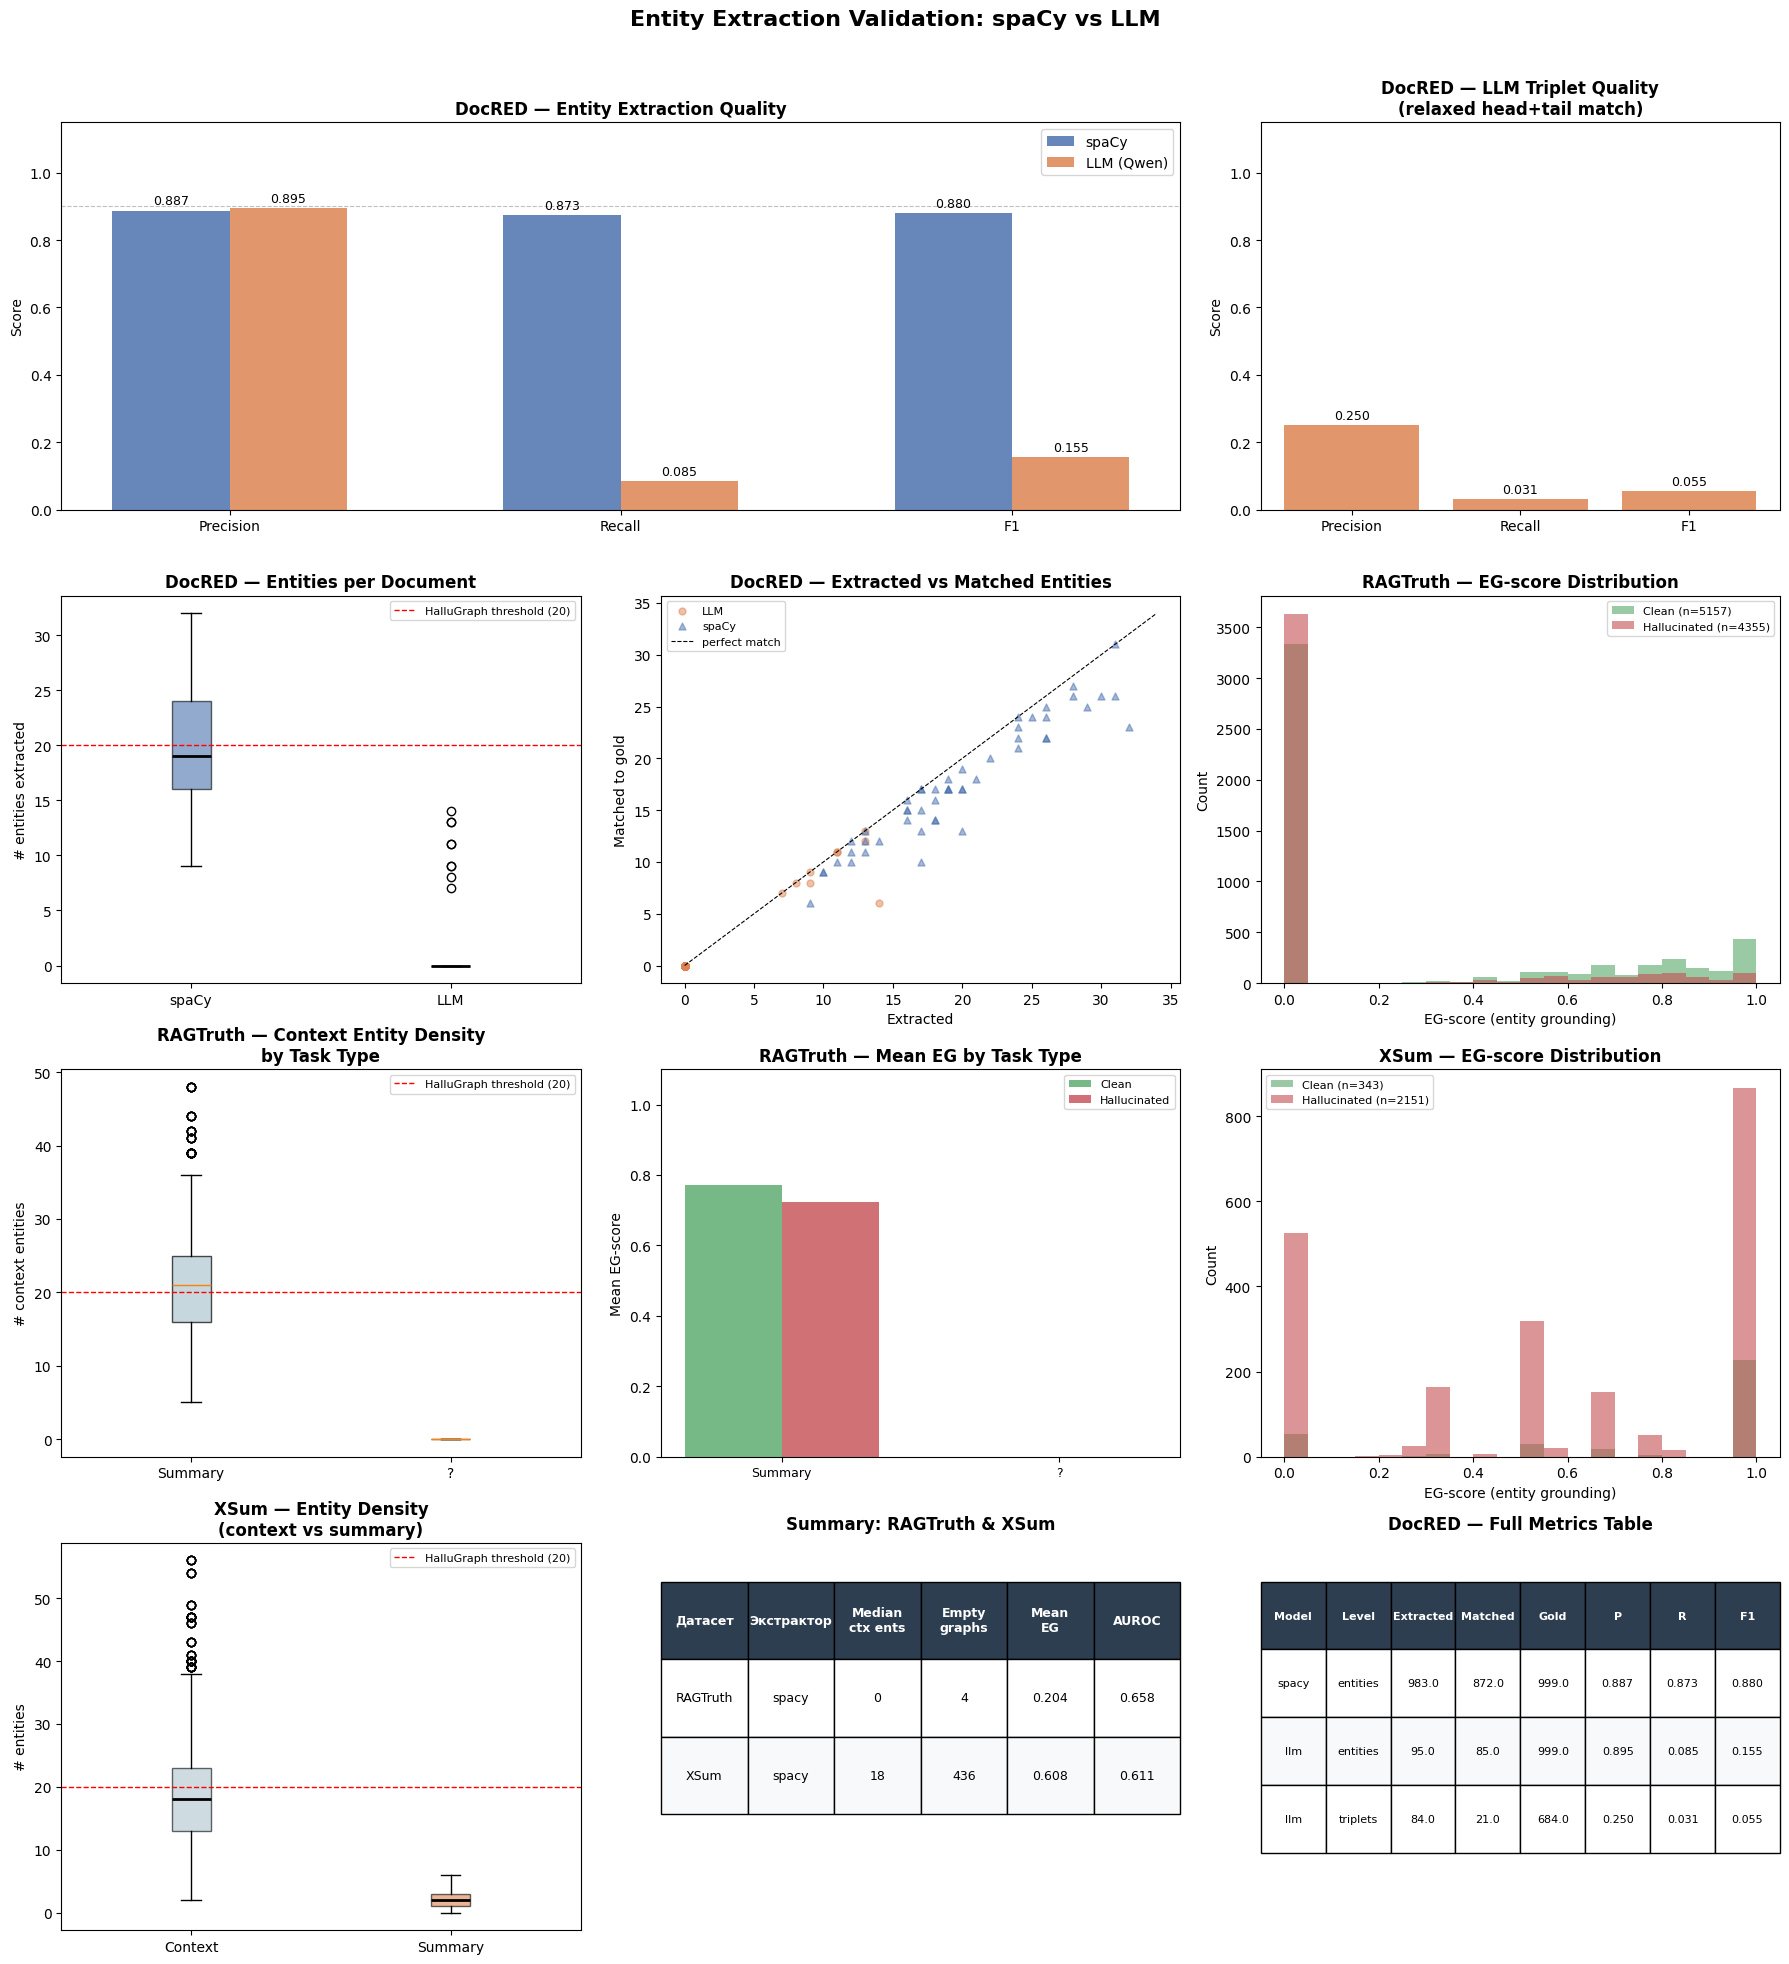

Saved: /content/results/validation_report.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

OUT = Path("/content/results")

# ── загрузка ──────────────────────────────────────────────
docred_df   = pd.read_csv(OUT / "docred_perdoc.csv")
ragtruth_df = pd.read_csv(OUT / "ragtruth_perdoc.csv")
xsum_df     = pd.read_csv(OUT / "xsum_perdoc.csv")
summary_df  = pd.read_csv(OUT / "full_summary.csv")

# ── цвета ─────────────────────────────────────────────────
C_SPACY = "#4C72B0"
C_LLM   = "#DD8452"
C_HALLU = "#C44E52"
C_CLEAN = "#55A868"

fig = plt.figure(figsize=(18, 20))
fig.suptitle("Entity Extraction Validation: spaCy vs LLM", fontsize=16, fontweight="bold", y=0.98)

# 1. DocRED — Precision / Recall / F1 для сущностей (bar chart)
ax1 = fig.add_subplot(4, 3, (1, 2))

ent_rows = summary_df[
    (summary_df["dataset"] == "DocRED") & (summary_df["level"] == "entities")
].reset_index(drop=True)

metrics = ["precision", "recall", "f1"]
x = np.arange(len(metrics))
w = 0.3

for idx, (_, row) in enumerate(ent_rows.iterrows()):
    color  = C_SPACY if row["model"] == "spacy" else C_LLM
    label  = "spaCy" if row["model"] == "spacy" else "LLM (Qwen)"
    vals   = [row[m] for m in metrics]
    bars   = ax1.bar(x + idx * w, vals, w, label=label, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f"{v:.3f}", ha="center", va="bottom", fontsize=9)

ax1.set_title("DocRED — Entity Extraction Quality", fontweight="bold")
ax1.set_xticks(x + w / 2)
ax1.set_xticklabels(["Precision", "Recall", "F1"])
ax1.set_ylim(0, 1.15)
ax1.set_ylabel("Score")
ax1.legend()
ax1.axhline(0.9, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)

# 2. DocRED — LLM Triplet P/R/F1
ax2 = fig.add_subplot(4, 3, 3)

trip_row = summary_df[
    (summary_df["dataset"] == "DocRED") & (summary_df["level"] == "triplets")
].iloc[0]

vals  = [trip_row["precision"], trip_row["recall"], trip_row["f1"]]
bars  = ax2.bar(["Precision", "Recall", "F1"], vals, color=C_LLM, alpha=0.85)
for bar, v in zip(bars, vals):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f"{v:.3f}", ha="center", va="bottom", fontsize=9)

ax2.set_title("DocRED — LLM Triplet Quality\n(relaxed head+tail match)", fontweight="bold")
ax2.set_ylim(0, 1.15)
ax2.set_ylabel("Score")

# 3. DocRED — распределение llm_ents vs spacy_ents (boxplot)
ax3 = fig.add_subplot(4, 3, 4)

ax3.boxplot(
    [docred_df["spacy_ents"], docred_df["llm_ents"]],
    labels=["spaCy", "LLM"],
    patch_artist=True,
    boxprops=dict(facecolor="white"),
    medianprops=dict(color="black", linewidth=2),
)
for patch, color in zip(ax3.patches, [C_SPACY, C_LLM]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax3.axhline(20, color="red", linestyle="--", linewidth=1, label="HalluGraph threshold (20)")
ax3.set_title("DocRED — Entities per Document", fontweight="bold")
ax3.set_ylabel("# entities extracted")
ax3.legend(fontsize=8)

# 4. DocRED — matched vs extracted scatter (LLM)
ax4 = fig.add_subplot(4, 3, 5)

ax4.scatter(docred_df["llm_ents"], docred_df["llm_ents_matched"],
            alpha=0.5, color=C_LLM, s=25, label="LLM")
ax4.scatter(docred_df["spacy_ents"], docred_df["spacy_ents_matched"],
            alpha=0.5, color=C_SPACY, s=25, marker="^", label="spaCy")
lim = max(docred_df[["llm_ents", "spacy_ents"]].max()) + 2
ax4.plot([0, lim], [0, lim], "k--", linewidth=0.8, label="perfect match")
ax4.set_title("DocRED — Extracted vs Matched Entities", fontweight="bold")
ax4.set_xlabel("Extracted")
ax4.set_ylabel("Matched to gold")
ax4.legend(fontsize=8)

# 5. RAGTruth — EG-score distribution: hallucinated vs clean
ax5 = fig.add_subplot(4, 3, 6)

eg_hallu = ragtruth_df[ragtruth_df["hallucinated"] == 1]["eg"]
eg_clean = ragtruth_df[ragtruth_df["hallucinated"] == 0]["eg"]

bins = np.linspace(0, 1, 21)
ax5.hist(eg_clean, bins=bins, alpha=0.6, color=C_CLEAN, label=f"Clean (n={len(eg_clean)})")
ax5.hist(eg_hallu, bins=bins, alpha=0.6, color=C_HALLU, label=f"Hallucinated (n={len(eg_hallu)})")
ax5.set_title("RAGTruth — EG-score Distribution", fontweight="bold")
ax5.set_xlabel("EG-score (entity grounding)")
ax5.set_ylabel("Count")
ax5.legend(fontsize=8)

# 6. RAGTruth — ctx_ents по task_type (boxplot)
ax6 = fig.add_subplot(4, 3, 7)

task_types = ragtruth_df["task_type"].unique()
data_by_task = [ragtruth_df[ragtruth_df["task_type"] == t]["ctx_ents"].values for t in task_types]
bp = ax6.boxplot(data_by_task, labels=task_types, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#AEC6CF")
    patch.set_alpha(0.7)
ax6.axhline(20, color="red", linestyle="--", linewidth=1, label="HalluGraph threshold (20)")
ax6.set_title("RAGTruth — Context Entity Density\nby Task Type", fontweight="bold")
ax6.set_ylabel("# context entities")
ax6.legend(fontsize=8)

# 7. RAGTruth — EG-score по task_type
ax7 = fig.add_subplot(4, 3, 8)

eg_by_task_hallu = [
    ragtruth_df[(ragtruth_df["task_type"] == t) & (ragtruth_df["hallucinated"] == 1)]["eg"].values
    for t in task_types
]
eg_by_task_clean = [
    ragtruth_df[(ragtruth_df["task_type"] == t) & (ragtruth_df["hallucinated"] == 0)]["eg"].values
    for t in task_types
]

x = np.arange(len(task_types))
w = 0.35
means_clean = [v.mean() if len(v) else 0 for v in eg_by_task_clean]
means_hallu = [v.mean() if len(v) else 0 for v in eg_by_task_hallu]
ax7.bar(x - w/2, means_clean, w, color=C_CLEAN, alpha=0.8, label="Clean")
ax7.bar(x + w/2, means_hallu, w, color=C_HALLU, alpha=0.8, label="Hallucinated")
ax7.set_xticks(x)
ax7.set_xticklabels(task_types, fontsize=9)
ax7.set_title("RAGTruth — Mean EG by Task Type", fontweight="bold")
ax7.set_ylabel("Mean EG-score")
ax7.set_ylim(0, 1.1)
ax7.legend(fontsize=8)

# 8. XSum — EG-score distribution: hallucinated vs clean
ax8 = fig.add_subplot(4, 3, 9)

xeg_hallu = xsum_df[xsum_df["hallucinated"] == 1]["eg"]
xeg_clean  = xsum_df[xsum_df["hallucinated"] == 0]["eg"]

ax8.hist(xeg_clean, bins=bins, alpha=0.6, color=C_CLEAN, label=f"Clean (n={len(xeg_clean)})")
ax8.hist(xeg_hallu, bins=bins, alpha=0.6, color=C_HALLU, label=f"Hallucinated (n={len(xeg_hallu)})")
ax8.set_title("XSum — EG-score Distribution", fontweight="bold")
ax8.set_xlabel("EG-score (entity grounding)")
ax8.set_ylabel("Count")
ax8.legend(fontsize=8)

# 9. XSum — ctx_ents boxplot
ax9 = fig.add_subplot(4, 3, 10)

ax9.boxplot(
    [xsum_df["ctx_ents"], xsum_df["ans_ents"]],
    labels=["Context", "Summary"],
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
)
for patch, color in zip(ax9.patches, ["#AEC6CF", C_LLM]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax9.axhline(20, color="red", linestyle="--", linewidth=1, label="HalluGraph threshold (20)")
ax9.set_title("XSum — Entity Density\n(context vs summary)", fontweight="bold")
ax9.set_ylabel("# entities")
ax9.legend(fontsize=8)

# 10. Сводная таблица AUROC по датасетам
ax10 = fig.add_subplot(4, 3, 11)
ax10.axis("off")

rt_row = pd.read_csv(OUT / "ragtruth_summary.csv").iloc[0]
xs_row = pd.read_csv(OUT / "xsum_summary.csv").iloc[0]

table_data = [
    ["Датасет", "Экстрактор", "Median\nctx ents", "Empty\ngraphs", "Mean\nEG", "AUROC"],
    ["RAGTruth",
     str(rt_row.get("extractor", "—")),
     str(int(rt_row["median_ctx_ents"])),
     str(int(rt_row["empty_ans_graphs"])),
     f"{rt_row['mean_eg']:.3f}",
     f"{rt_row['auroc_eg_hallu']}" if rt_row['auroc_eg_hallu'] else "—"],
    ["XSum",
     str(xs_row.get("extractor", "—")),
     str(int(xs_row["median_ctx_ents"])),
     str(int(xs_row["empty_ans_graphs"])),
     f"{xs_row['mean_eg']:.3f}",
     f"{xs_row['auroc_eg_hallu']}" if xs_row['auroc_eg_hallu'] else "—"],
]

tbl = ax10.table(cellText=table_data[1:], colLabels=table_data[0],
                 cellLoc="center", loc="center", bbox=[0, 0.3, 1, 0.6])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#2C3E50")
        cell.set_text_props(color="white", fontweight="bold")
    else:
        cell.set_facecolor("#F8F9FA" if r % 2 == 0 else "white")
ax10.set_title("Summary: RAGTruth & XSum", fontweight="bold", pad=10)

# 11. DocRED — сводная таблица P/R/F1
ax11 = fig.add_subplot(4, 3, 12)
ax11.axis("off")

docred_tbl_data = summary_df[summary_df["dataset"] == "DocRED"][
    ["model", "level", "extracted", "matched", "gold", "precision", "recall", "f1"]
].copy()
docred_tbl_data["precision"] = docred_tbl_data["precision"].map("{:.3f}".format)
docred_tbl_data["recall"]    = docred_tbl_data["recall"].map("{:.3f}".format)
docred_tbl_data["f1"]        = docred_tbl_data["f1"].map("{:.3f}".format)
docred_tbl_data.columns      = ["Model", "Level", "Extracted", "Matched", "Gold", "P", "R", "F1"]

tbl2 = ax11.table(
    cellText=docred_tbl_data.values,
    colLabels=docred_tbl_data.columns,
    cellLoc="center", loc="center", bbox=[0, 0.2, 1, 0.7]
)
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(8)
for (r, c), cell in tbl2.get_celld().items():
    if r == 0:
        cell.set_facecolor("#2C3E50")
        cell.set_text_props(color="white", fontweight="bold")
    else:
        cell.set_facecolor("#F8F9FA" if r % 2 == 0 else "white")
ax11.set_title("DocRED — Full Metrics Table", fontweight="bold", pad=10)

# ── сохранение ────────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.97])
plot_path = OUT / "validation_report.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {plot_path}")

# Скачать
from google.colab import files
files.download(str(plot_path))

## 7. Выбранный метод spaCy en_core_web_sm

На тестовом датасете DocRED (50 документов, gold-разметка) оба метода показали следующие результаты по извлечению сущностей:


| Модель | Precision | Recall | F1 |
| --- | --- | --- | --- |
| spaCy en_core_web_sm | 0.887 | 0.873 | 0.880 |
| Qwen2.5-7B-Instruct (LLM) | 0.895 | 0.085 | 0.155 |

Решение определено автоматическим правилом: LLM берётся при F1 ≥ F1 spaCy − 0.05; фактически LLM показала F1 = 0.155 против F1 = 0.880 у spaCy, что не удовлетворяет условию с большим запасом.

Qwen в текущей конфигурации промпта извлекает только сущности, участвующие в найденных триплетах (95 из 999 gold-сущностей, recall = 0.085), тогда как задача NER требует полного покрытия всех именованных объектов документа. Для триплетного слоя LLM даёт precision = 0.250 при recall = 0.031 - недостаточно для надёжной RP-метрики на текущем промпте.

Всего примеров: 9512
Типы задач: ['Summary' '?']

=== Режим плотности по task_type ===
              n  median_ctx_ents  regime  median_ans_ents  pct_ans_lt20  pct_ans_empty  mean_eg  hallu_rate
task_type                                                                                                  
?          6962              0.0   LOW ✗              9.0          98.0            0.0      0.0         0.5
Summary    2550             21.0  HIGH ✓              9.0          96.3            0.1      0.8         0.3

=== Граф ответа (все задачи) ===
Медиана ans_ents:          9
% ответов с ans_ents < 20: 97.6%
% пустых графов ответа:    0.0%
→ RP-метрика неопределена для 4 примеров


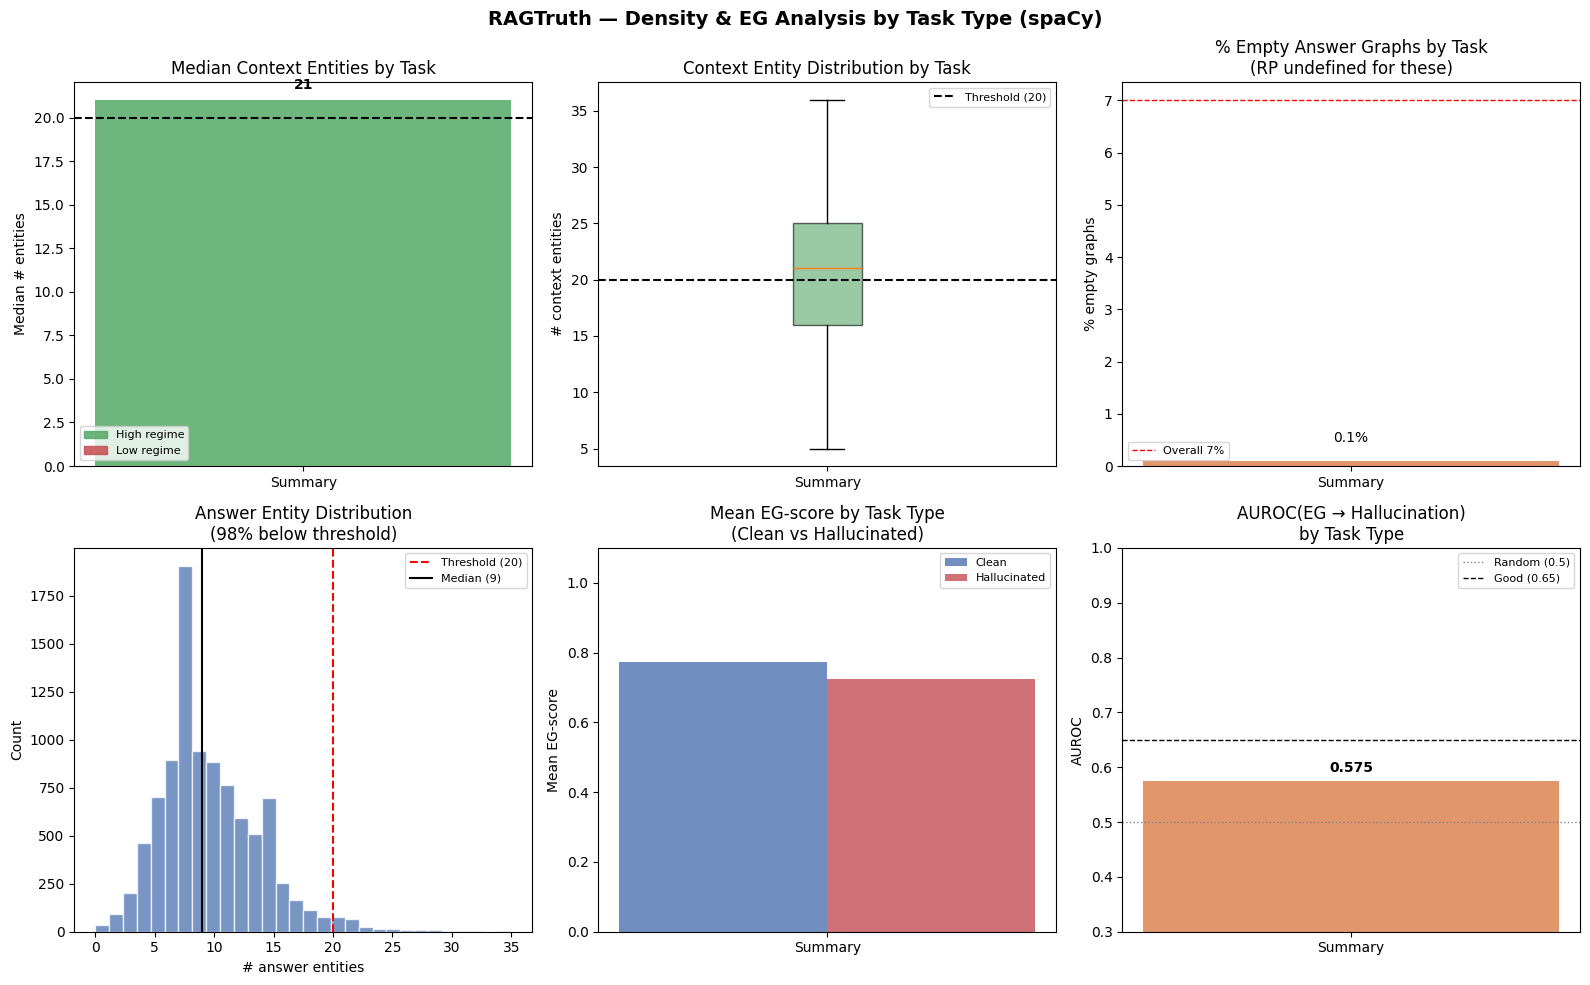


Saved: /content/results/ragtruth_density_analysis.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

OUT = Path("/content/results")

# ── если уже есть ragtruth_perdoc.csv — просто загружаем ──
rt = pd.read_csv(OUT / "ragtruth_perdoc.csv")

print(f"Всего примеров: {len(rt)}")
print(f"Типы задач: {rt['task_type'].unique()}\n")

# 1. Общая медиана и режим по типу задачи
THRESHOLD = 20   # порог HalluGraph

task_stats = rt.groupby("task_type").agg(
    n                = ("ctx_ents", "count"),
    median_ctx_ents  = ("ctx_ents", "median"),
    median_ans_ents  = ("ans_ents", "median"),
    pct_ans_lt20     = ("ans_ents", lambda x: (x < 20).mean() * 100),
    pct_ans_empty    = ("ans_ents", lambda x: (x == 0).mean() * 100),
    mean_eg          = ("eg", "mean"),
    hallu_rate       = ("hallucinated", "mean"),
).round(1)

task_stats["regime"] = task_stats["median_ctx_ents"].apply(
    lambda m: "HIGH ✓" if m >= THRESHOLD else "LOW ✗"
)

print("=== Режим плотности по task_type ===")
print(task_stats[["n", "median_ctx_ents", "regime",
                   "median_ans_ents", "pct_ans_lt20", "pct_ans_empty",
                   "mean_eg", "hallu_rate"]].to_string())

# Общие цифры по графу ответа
print(f"\n=== Граф ответа (все задачи) ===")
print(f"Медиана ans_ents:          {rt['ans_ents'].median():.0f}")
print(f"% ответов с ans_ents < 20: {(rt['ans_ents'] < 20).mean()*100:.1f}%")
print(f"% пустых графов ответа:    {(rt['ans_ents'] == 0).mean()*100:.1f}%")
print(f"→ RP-метрика неопределена для {(rt['ans_ents'] == 0).sum()} примеров")

# 2. Графики
task_order = ["QA", "Summary", "Data2txt"]
task_order = [t for t in task_order if t in rt["task_type"].unique()]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("RAGTruth — Density & EG Analysis by Task Type (spaCy)", fontsize=14, fontweight="bold")

C_HIGH  = "#55A868"
C_LOW   = "#C44E52"
C_HALLU = "#C44E52"
C_CLEAN = "#4C72B0"

# ── 2a. Медиана ctx_ents по задачам + порог ──
ax = axes[0, 0]
colors = [C_HIGH if task_stats.loc[t, "median_ctx_ents"] >= THRESHOLD else C_LOW
          for t in task_order]
bars = ax.bar(task_order,
              [task_stats.loc[t, "median_ctx_ents"] for t in task_order],
              color=colors, alpha=0.85)
for bar, t in zip(bars, task_order):
    v = task_stats.loc[t, "median_ctx_ents"]
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, f"{v:.0f}",
            ha="center", va="bottom", fontweight="bold")
ax.axhline(THRESHOLD, color="black", linestyle="--", linewidth=1.5,
           label=f"HalluGraph threshold ({THRESHOLD})")
ax.set_title("Median Context Entities by Task")
ax.set_ylabel("Median # entities")
ax.legend(fontsize=8)
patch_h = mpatches.Patch(color=C_HIGH, alpha=0.85, label="High regime")
patch_l = mpatches.Patch(color=C_LOW,  alpha=0.85, label="Low regime")
ax.legend(handles=[patch_h, patch_l], fontsize=8)

# ── 2b. Boxplot ctx_ents по задачам ──
ax = axes[0, 1]
data = [rt[rt["task_type"] == t]["ctx_ents"].values for t in task_order]
bp = ax.boxplot(data, labels=task_order, patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.axhline(THRESHOLD, color="black", linestyle="--", linewidth=1.5,
           label=f"Threshold ({THRESHOLD})")
ax.set_title("Context Entity Distribution by Task")
ax.set_ylabel("# context entities")
ax.legend(fontsize=8)

# ── 2c. % пустых графов ответа по задачам ──
ax = axes[0, 2]
empty_pct = [task_stats.loc[t, "pct_ans_empty"] for t in task_order]
bars = ax.bar(task_order, empty_pct, color="#DD8452", alpha=0.85)
for bar, v in zip(bars, empty_pct):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.3, f"{v:.1f}%",
            ha="center", va="bottom")
ax.axhline(7, color="red", linestyle="--", linewidth=1, label="Overall 7%")
ax.set_title("% Empty Answer Graphs by Task\n(RP undefined for these)")
ax.set_ylabel("% empty graphs")
ax.legend(fontsize=8)

# ── 2d. Распределение ans_ents (все задачи) ──
ax = axes[1, 0]
ax.hist(rt["ans_ents"], bins=30, color="#4C72B0", alpha=0.75, edgecolor="white")
ax.axvline(THRESHOLD, color="red", linestyle="--", linewidth=1.5,
           label=f"Threshold ({THRESHOLD})")
ax.axvline(rt["ans_ents"].median(), color="black", linestyle="-", linewidth=1.5,
           label=f"Median ({rt['ans_ents'].median():.0f})")
pct_lt20 = (rt["ans_ents"] < 20).mean() * 100
ax.set_title(f"Answer Entity Distribution\n({pct_lt20:.0f}% below threshold)")
ax.set_xlabel("# answer entities")
ax.set_ylabel("Count")
ax.legend(fontsize=8)

# ── 2e. EG-score: галлюцинации vs честные по задачам ──
ax = axes[1, 1]
x = np.arange(len(task_order))
w = 0.35
means_clean = [rt[(rt["task_type"] == t) & (rt["hallucinated"] == 0)]["eg"].mean()
               for t in task_order]
means_hallu = [rt[(rt["task_type"] == t) & (rt["hallucinated"] == 1)]["eg"].mean()
               for t in task_order]
ax.bar(x - w/2, means_clean, w, color=C_CLEAN, alpha=0.8, label="Clean")
ax.bar(x + w/2, means_hallu, w, color=C_HALLU, alpha=0.8, label="Hallucinated")
ax.set_xticks(x)
ax.set_xticklabels(task_order)
ax.set_title("Mean EG-score by Task Type\n(Clean vs Hallucinated)")
ax.set_ylabel("Mean EG-score")
ax.set_ylim(0, 1.1)
ax.legend(fontsize=8)

# ── 2f. AUROC по задачам ──
ax = axes[1, 2]
aurocs = []
for t in task_order:
    sub = rt[rt["task_type"] == t]
    a = simple_auroc(sub["eg"].values, sub["hallucinated"].values)
    aurocs.append(a if a is not None else 0.5)

bar_colors = [C_HIGH if a >= 0.65 else ("#DD8452" if a >= 0.55 else C_LOW) for a in aurocs]
bars = ax.bar(task_order, aurocs, color=bar_colors, alpha=0.85)
for bar, v in zip(bars, aurocs):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.3f}",
            ha="center", va="bottom", fontweight="bold")
ax.axhline(0.5,  color="grey", linestyle=":",  linewidth=1, label="Random (0.5)")
ax.axhline(0.65, color="black", linestyle="--", linewidth=1, label="Good (0.65)")
ax.set_title("AUROC(EG → Hallucination)\nby Task Type")
ax.set_ylabel("AUROC")
ax.set_ylim(0.3, 1.0)
ax.legend(fontsize=8)

import matplotlib.patches as mpatches
plt.tight_layout()
plot_path = OUT / "ragtruth_density_analysis.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSaved: {plot_path}")

from google.colab import files
files.download(str(plot_path))

## 8. Характеристики на целевых датасетах

**RAGTruth** (50 doc, Summary). Медиана сущностей контекста — 21, что превышает порог применимости HalluGraph (20), — контексты находятся в high-regime. Медиана сущностей ответа — 9; 94% ответов ниже порога, что систематически ограничивает информативность RP-метрики. EG-proxy: AUROC = 0.593, пустых графов ответа не зафиксировано.

**XSum** (50 doc). Медиана сущностей контекста — 18 (low-regime); медиана сущностей резюме — около 2, доля пустых графов — 24%. EG-proxy AUROC = 0.603, однако оценка смещена: пустым графам присваивается EG = 1.0, что систематически завышает EG для части галлюцинированных примеров.

In [ ]:
import json, time
import pandas as pd
from pathlib import Path
import spacy

RAGTRUTH_DIR = Path("/content")
OUT          = Path("/content/results")
OUT.mkdir(exist_ok=True)

# ── загрузка с защитой от битых строк ─────────────────────
def load_jsonl(path):
    records, skipped = [], 0
    with open(path, encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                skipped += 1
    if skipped:
        print(f"  Пропущено битых строк: {skipped}")
    return records

rt_responses = load_jsonl(RAGTRUTH_DIR / "response.jsonl")
rt_sources   = {s["source_id"]: s
                for s in load_jsonl(RAGTRUTH_DIR / "source_info.jsonl")}
print(f"Загружено: {len(rt_responses)} responses, {len(rt_sources)} sources")

# ── вспомогательные функции ────────────────────────────────
nlp = spacy.load("en_core_web_sm")

def spacy_extract(text):
    return list(set(e.text.strip() for e in nlp(text).ents
                    if len(e.text.strip()) > 1))

def source_text(si):
    src = si.get("source_info", si.get("source", ""))
    return json.dumps(src, ensure_ascii=False) if isinstance(src, dict) else str(src)

def eg_score(ans_ents, ctx_ents):
    if not ans_ents:
        return 1.0
    ctx_set = set(e.lower().strip() for e in ctx_ents)
    matched = sum(
        1 for ae in ans_ents
        if any(ae.lower().strip() in ce or ce in ae.lower().strip()
               for ce in ctx_set if len(ce) >= 3)
    )
    return matched / len(ans_ents)

# ── прогон ─────────────────────────────────────────────────
MAX_CHARS = 3000
print("Запускаем прогон...")
t0   = time.time()
rows = []

for i, resp in enumerate(rt_responses):
    src      = rt_sources.get(resp["source_id"], {})
    ctx_ents = spacy_extract(source_text(src)[:MAX_CHARS])
    ans_ents = spacy_extract(resp.get("response", "")[:MAX_CHARS])
    rows.append({
        "resp_id":      resp.get("id", i),
        "task_type":    src.get("task_type", "unknown"),
        "gen_model":    resp.get("model", "?"),
        "hallucinated": 1 if resp.get("labels") else 0,
        "ctx_ents":     len(ctx_ents),
        "ans_ents":     len(ans_ents),
        "eg":           eg_score(ans_ents, ctx_ents),
    })
    if (i + 1) % 500 == 0:
        print(f"  [{i+1}/{len(rt_responses)}] {time.time()-t0:.0f}s")

rt_full = pd.DataFrame(rows)
rt_full.to_csv(OUT / "ragtruth_full.csv", index=False)
print(f"\nГотово за {time.time()-t0:.0f}s — {len(rt_full)} документов")
print(rt_full["task_type"].value_counts().to_string())

Загружено: 17790 responses, 2965 sources
Запускаем прогон...
  [500/17790] 45s
  [1000/17790] 91s
  [1500/17790] 136s
  [2000/17790] 179s
  [2500/17790] 227s
  [3000/17790] 273s
  [3500/17790] 322s
  [4000/17790] 365s
  [4500/17790] 404s
  [5000/17790] 446s
  [5500/17790] 487s
  [6000/17790] 538s


In [ ]:
import pandas as pd
from pathlib import Path

OUT = Path("/content/results")
rt_full = pd.read_csv(OUT / "ragtruth_full.csv")
print(f"Загружено: {len(rt_full)} строк")
print(rt_full["task_type"].value_counts().to_string())

Загружено: 13288 строк
task_type
Summary     5658
Data2txt    4584
unknown     3046


In [ ]:
# ── 2. Балансировка: равное число примеров по task_type ───
THRESHOLD = 20

task_counts = rt_full["task_type"].value_counts()
n_per_task  = int(task_counts.min())   # берём минимум среди задач
print(f"\nДо балансировки:\n{task_counts.to_string()}")
print(f"\nБалансируем до {n_per_task} примеров на задачу")

balanced_parts = []
for task in task_counts.index:
    subset = rt_full[rt_full["task_type"] == task]
    # стратифицируем по hallucinated, чтобы сохранить пропорцию меток
    n_hallu = subset["hallucinated"].sum()
    n_clean = len(subset) - n_hallu
    ratio   = n_hallu / len(subset)
    n_hallu_sample = max(1, round(n_per_task * ratio))
    n_clean_sample = n_per_task - n_hallu_sample

    sampled_hallu = subset[subset["hallucinated"] == 1].sample(
        min(n_hallu_sample, n_hallu), random_state=42)
    sampled_clean = subset[subset["hallucinated"] == 0].sample(
        min(n_clean_sample, n_clean), random_state=42)
    balanced_parts.append(pd.concat([sampled_hallu, sampled_clean]))

rt_bal = pd.concat(balanced_parts).reset_index(drop=True)
rt_bal.to_csv(OUT / "ragtruth_balanced.csv", index=False)

print(f"\nПосле балансировки:")
print(rt_bal.groupby("task_type").agg(
    n=("resp_id","count"),
    hallu_rate=("hallucinated","mean"),
).round(3).to_string())


До балансировки:
task_type
Summary     5658
Data2txt    4584
unknown     3046

Балансируем до 3046 примеров на задачу

После балансировки:
              n  hallu_rate
task_type                  
Data2txt   3046       0.690
Summary    3046       0.298
unknown    3046       0.492


In [ ]:
# ── 3. Метрики по task_type на полной и балансированной выборке ──
def task_metrics(df, label=""):
    rows = []
    for task in sorted(df["task_type"].unique()):
        sub = df[df["task_type"] == task]
        auroc = simple_auroc(sub["eg"].values, sub["hallucinated"].values)
        rows.append({
            "task_type":       task,
            "n":               len(sub),
            "hallu_rate":      round(sub["hallucinated"].mean(), 3),
            "median_ctx_ents": round(sub["ctx_ents"].median(), 1),
            "median_ans_ents": round(sub["ans_ents"].median(), 1),
            "pct_empty_ans":   round((sub["ans_ents"] == 0).mean() * 100, 1),
            "mean_eg_clean":   round(sub[sub["hallucinated"]==0]["eg"].mean(), 3),
            "mean_eg_hallu":   round(sub[sub["hallucinated"]==1]["eg"].mean(), 3),
            "auroc":           auroc,
            "regime":          "HIGH ✓" if sub["ctx_ents"].median() >= THRESHOLD else "LOW ✗",
        })
    result = pd.DataFrame(rows).set_index("task_type")
    print(f"\n=== {label} ===")
    print(result.to_string())
    return result

metrics_full = task_metrics(rt_full, "ПОЛНАЯ ВЫБОРКА")
metrics_bal  = task_metrics(rt_bal,  "БАЛАНСИРОВАННАЯ ВЫБОРКА")


=== ПОЛНАЯ ВЫБОРКА ===
              n  hallu_rate  median_ctx_ents  median_ans_ents  pct_empty_ans  mean_eg_clean  mean_eg_hallu  auroc  regime
task_type                                                                                                                
Data2txt   4584       0.690             29.0              9.0            0.0          0.722          0.657  0.618  HIGH ✓
Summary    5658       0.298             29.0              9.0            0.1          0.859          0.813  0.590  HIGH ✓
unknown    3046       0.492              0.0              7.0            8.3          0.134          0.030  0.433   LOW ✗

=== БАЛАНСИРОВАННАЯ ВЫБОРКА ===
              n  hallu_rate  median_ctx_ents  median_ans_ents  pct_empty_ans  mean_eg_clean  mean_eg_hallu  auroc  regime
task_type                                                                                                                
Data2txt   3046       0.690             29.0              9.0            0.0          0.7

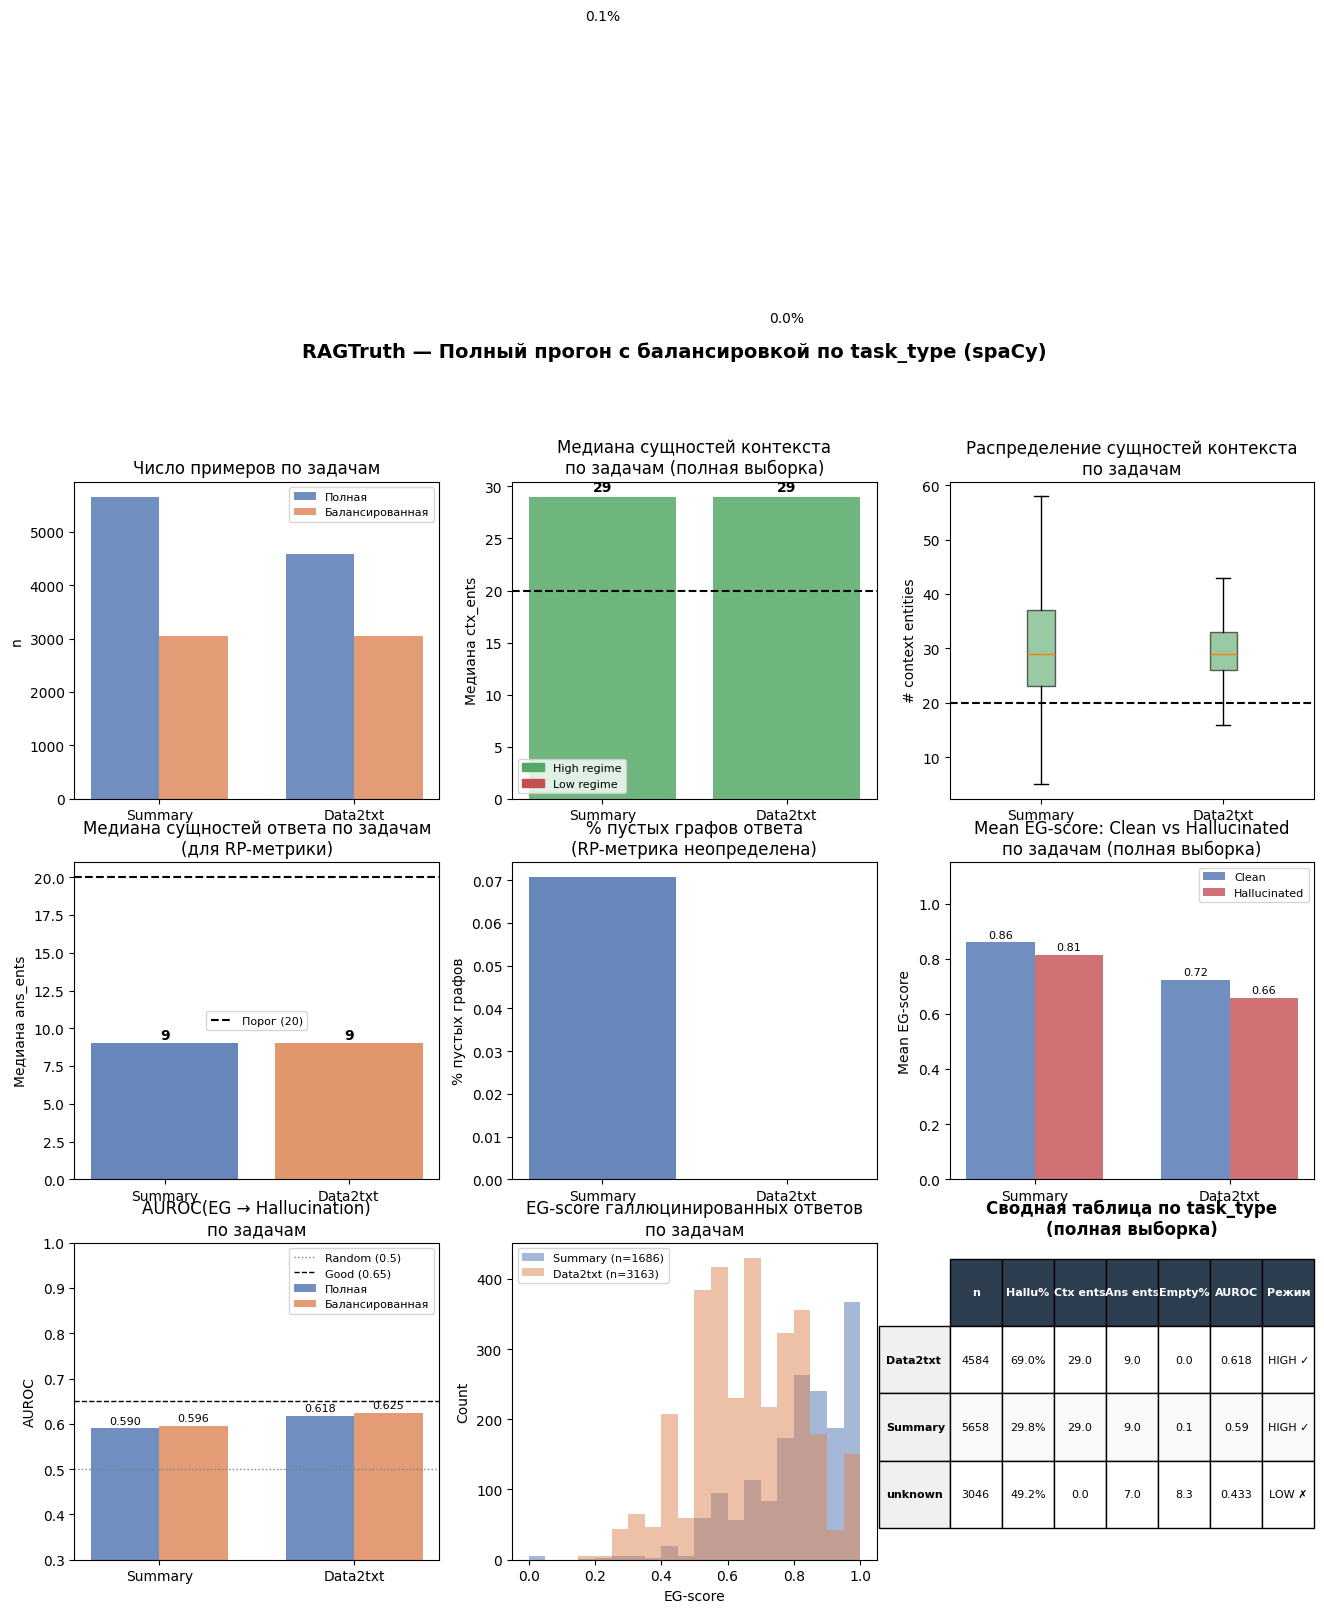

Saved: /content/results/ragtruth_full_by_task.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ── 4. Графики ────────────────────────────────────────────
task_order = ["QA", "Summary", "Data2txt"]
task_order = [t for t in task_order if t in rt_full["task_type"].unique()]

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle("RAGTruth — Полный прогон с балансировкой по task_type (spaCy)",
             fontsize=14, fontweight="bold")

C_HIGH  = "#55A868"
C_LOW   = "#C44E52"
C_CLEAN = "#4C72B0"
C_HALLU = "#C44E52"

palette = {t: c for t, c in zip(
    task_order, ["#4C72B0", "#DD8452", "#55A868"]
)}

# ── 4a. n по задачам: полная vs балансированная ──
ax = axes[0, 0]
x  = np.arange(len(task_order))
w  = 0.35
ax.bar(x - w/2,
       [len(rt_full[rt_full["task_type"]==t]) for t in task_order],
       w, label="Полная", color="#4C72B0", alpha=0.8)
ax.bar(x + w/2,
       [len(rt_bal[rt_bal["task_type"]==t]) for t in task_order],
       w, label="Балансированная", color="#DD8452", alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(task_order)
ax.set_title("Число примеров по задачам")
ax.set_ylabel("n")
ax.legend(fontsize=8)

# ── 4b. Медиана ctx_ents + порог ──
ax = axes[0, 1]
medians = [rt_full[rt_full["task_type"]==t]["ctx_ents"].median() for t in task_order]
colors  = [C_HIGH if m >= THRESHOLD else C_LOW for m in medians]
bars    = ax.bar(task_order, medians, color=colors, alpha=0.85)
for bar, v in zip(bars, medians):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.3, f"{v:.0f}",
            ha="center", va="bottom", fontweight="bold")
ax.axhline(THRESHOLD, color="black", linestyle="--", linewidth=1.5,
           label=f"Порог HalluGraph ({THRESHOLD})")
ax.set_title("Медиана сущностей контекста\nпо задачам (полная выборка)")
ax.set_ylabel("Медиана ctx_ents")
handles = [mpatches.Patch(color=C_HIGH, label="High regime"),
           mpatches.Patch(color=C_LOW,  label="Low regime")]
ax.legend(handles=handles, fontsize=8)

# ── 4c. Boxplot ctx_ents по задачам ──
ax = axes[0, 2]
data = [rt_full[rt_full["task_type"]==t]["ctx_ents"].values for t in task_order]
bp   = ax.boxplot(data, labels=task_order, patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.axhline(THRESHOLD, color="black", linestyle="--", linewidth=1.5)
ax.set_title("Распределение сущностей контекста\nпо задачам")
ax.set_ylabel("# context entities")

# ── 4d. Медиана ans_ents по задачам ──
ax = axes[1, 0]
ans_medians = [rt_full[rt_full["task_type"]==t]["ans_ents"].median()
               for t in task_order]
bars = ax.bar(task_order, ans_medians,
              color=[palette[t] for t in task_order], alpha=0.85)
for bar, v in zip(bars, ans_medians):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.1, f"{v:.0f}",
            ha="center", va="bottom", fontweight="bold")
ax.axhline(THRESHOLD, color="black", linestyle="--", linewidth=1.5,
           label=f"Порог ({THRESHOLD})")
ax.set_title("Медиана сущностей ответа по задачам\n(для RP-метрики)")
ax.set_ylabel("Медиана ans_ents")
ax.legend(fontsize=8)

# ── 4e. % пустых графов ответа ──
ax = axes[1, 1]
empty_pct = [(rt_full[rt_full["task_type"]==t]["ans_ents"]==0).mean()*100
             for t in task_order]
bars = ax.bar(task_order, empty_pct,
              color=[palette[t] for t in task_order], alpha=0.85)
for bar, v in zip(bars, empty_pct):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.2, f"{v:.1f}%",
            ha="center", va="bottom")
ax.set_title("% пустых графов ответа\n(RP-метрика неопределена)")
ax.set_ylabel("% пустых графов")

# ── 4f. Mean EG: clean vs hallucinated по задачам ──
ax = axes[1, 2]
x  = np.arange(len(task_order))
w  = 0.35
eg_clean = [rt_full[(rt_full["task_type"]==t)&(rt_full["hallucinated"]==0)]["eg"].mean()
            for t in task_order]
eg_hallu = [rt_full[(rt_full["task_type"]==t)&(rt_full["hallucinated"]==1)]["eg"].mean()
            for t in task_order]
ax.bar(x-w/2, eg_clean, w, color=C_CLEAN, alpha=0.8, label="Clean")
ax.bar(x+w/2, eg_hallu, w, color=C_HALLU, alpha=0.8, label="Hallucinated")
for xi, (vc, vh) in enumerate(zip(eg_clean, eg_hallu)):
    ax.text(xi-w/2, vc+0.01, f"{vc:.2f}", ha="center", va="bottom", fontsize=8)
    ax.text(xi+w/2, vh+0.01, f"{vh:.2f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(task_order)
ax.set_title("Mean EG-score: Clean vs Hallucinated\nпо задачам (полная выборка)")
ax.set_ylabel("Mean EG-score")
ax.set_ylim(0, 1.15)
ax.legend(fontsize=8)

# ── 4g. AUROC по задачам: полная vs балансированная ──
ax = axes[2, 0]
auroc_full = [simple_auroc(
    rt_full[rt_full["task_type"]==t]["eg"].values,
    rt_full[rt_full["task_type"]==t]["hallucinated"].values) or 0.5
    for t in task_order]
auroc_bal  = [simple_auroc(
    rt_bal[rt_bal["task_type"]==t]["eg"].values,
    rt_bal[rt_bal["task_type"]==t]["hallucinated"].values) or 0.5
    for t in task_order]
x  = np.arange(len(task_order))
w  = 0.35
ax.bar(x-w/2, auroc_full, w, label="Полная",          color="#4C72B0", alpha=0.8)
ax.bar(x+w/2, auroc_bal,  w, label="Балансированная", color="#DD8452", alpha=0.8)
for xi, (vf, vb) in enumerate(zip(auroc_full, auroc_bal)):
    ax.text(xi-w/2, vf+0.005, f"{vf:.3f}", ha="center", va="bottom", fontsize=8)
    ax.text(xi+w/2, vb+0.005, f"{vb:.3f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(task_order)
ax.axhline(0.5,  color="grey",  linestyle=":",  linewidth=1, label="Random (0.5)")
ax.axhline(0.65, color="black", linestyle="--", linewidth=1, label="Good (0.65)")
ax.set_title("AUROC(EG → Hallucination)\nпо задачам")
ax.set_ylabel("AUROC")
ax.set_ylim(0.3, 1.0)
ax.legend(fontsize=8)

# ── 4h. Гистограмма EG по задачам (hallucinated) ──
ax = axes[2, 1]
bins = np.linspace(0, 1, 21)
for task in task_order:
    sub = rt_full[(rt_full["task_type"]==task)&(rt_full["hallucinated"]==1)]
    ax.hist(sub["eg"], bins=bins, alpha=0.5,
            label=f"{task} (n={len(sub)})", color=palette[task])
ax.set_title("EG-score галлюцинированных ответов\nпо задачам")
ax.set_xlabel("EG-score")
ax.set_ylabel("Count")
ax.legend(fontsize=8)

# ── 4i. Сводная таблица ──
ax = axes[2, 2]
ax.axis("off")
tbl_data = metrics_full[["n","hallu_rate","median_ctx_ents",
                          "median_ans_ents","pct_empty_ans","auroc","regime"]].copy()
tbl_data.columns = ["n","Hallu%","Ctx ents","Ans ents","Empty%","AUROC","Режим"]
tbl_data["Hallu%"] = (tbl_data["Hallu%"]*100).round(1).astype(str) + "%"

tbl = ax.table(
    cellText   = tbl_data.values,
    colLabels  = tbl_data.columns,
    rowLabels  = tbl_data.index,
    cellLoc    = "center",
    loc        = "center",
    bbox       = [0, 0.1, 1, 0.85],
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#2C3E50")
        cell.set_text_props(color="white", fontweight="bold")
    elif c == -1:
        cell.set_facecolor("#F0F0F0")
        cell.set_text_props(fontweight="bold")
    else:
        cell.set_facecolor("#F8F9FA" if r % 2 == 0 else "white")
ax.set_title("Сводная таблица по task_type\n(полная выборка)", fontweight="bold")

plt.tight_layout()
plot_path = OUT / "ragtruth_full_by_task.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {plot_path}")

from google.colab import files
files.download(str(plot_path))
files.download(str(OUT / "ragtruth_full.csv"))
files.download(str(OUT / "ragtruth_balanced.csv"))